# Group Leakage: What Does Your Validation Measure?

**Research question.** Can a model with no transferable signal score above 0.9 AUC?

Original controlled experiment by Zangar. This notebook runs offline and uses synthetic data, never real personal records. [Source and reproduction instructions](https://github.com/zoga228/validation-stress-lab).

AI tools assisted implementation and editing; all reported measurements come from executed code.

## Experimental protocol

We evaluate five seeds with the same model. A random row split tests new records from previously seen groups; a disjoint group split tests entirely new groups. The only useful feature in this controlled generator is an arbitrary group identity. Neither score is universally correct: choose the protocol that matches deployment.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
import numpy as np, pandas as pd, sklearn, matplotlib
print({'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__,'matplotlib':matplotlib.__version__})

{'numpy': '2.2.6', 'pandas': '2.3.1', 'sklearn': '1.7.1', 'matplotlib': '3.10.6'}


## Data-generating process

The generator is included so every assumption is inspectable. A downloadable CSV version is attached; the seeds below regenerate the same benchmark without file-path dependencies. Synthetic results illustrate a failure mode and do not establish performance on real data.

In [2]:
"""Original synthetic benchmarks; no real people, records, or competition data."""
import json
from pathlib import Path
import numpy as np
import pandas as pd


def grouped(seed=42, groups=400, repeats=30):
    rng = np.random.default_rng(seed)
    ids = np.repeat(np.arange(groups), repeats)
    latent = rng.integers(0, 2, size=groups)
    flip = rng.random(len(ids)) < .08
    return pd.DataFrame({"group_id": ids.astype(str), "sensor_noise": rng.normal(size=len(ids)), "target": np.logical_xor(latent[ids], flip).astype(int)})


def missingness(seed=42, n=6000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, 6))
    score = 1.6*x[:, 0] - .8*x[:, 1] + .5*x[:, 2]*x[:, 3]
    y = (rng.random(n) < 1 / (1 + np.exp(-score))).astype(int)
    # An apparent signal reverses at deployment. This is a controlled stress test.
    correlated = (y + rng.normal(0, .4, n)) if not shifted else ((1-y) + rng.normal(0, .4, n))
    missing = rng.random(n) < np.where(y == 1, .3 if not shifted else .7, .1 if not shifted else .4)
    x[missing, 0] = np.nan
    df = pd.DataFrame(x, columns=[f"x{i}" for i in range(6)])
    df["spurious"] = correlated
    df["target"] = y
    return df


def regression(seed=42, n=4000, shifted=False):
    rng = np.random.default_rng(seed)
    x = rng.normal(1.8 if shifted else 0, 1, n)
    sigma = .3 + .4*np.abs(x)
    y = np.sin(2*x) + .5*x + sigma*rng.normal(size=n)
    return pd.DataFrame({"x": x, "target": y})


def export(root):
    root = Path(root)
    specs = {
        "grouped-validation": {"all.csv": grouped()},
        "missingness-shift": {"train.csv": missingness(42), "iid-test.csv": missingness(43, 3000), "shift-test.csv": missingness(44, 3000, True)},
        "conformal-shift": {"train.csv": regression(42), "calibration.csv": regression(43, 2000), "iid-test.csv": regression(44, 3000), "shift-test.csv": regression(45, 3000, True)},
    }
    for name, files in specs.items():
        folder = root / name
        folder.mkdir(parents=True, exist_ok=True)
        for filename, frame in files.items():
            frame.to_csv(folder / filename, index=False)
        info = {"synthetic": True, "license": "CC0-1.0", "generator": "make_data.py", "version": "1.0", "files": {k: {"rows": len(v), "columns": list(v)} for k, v in files.items()}, "purpose": "Controlled experiments about validation assumptions; not evidence about a real population"}
        (folder / "data-card.json").write_text(json.dumps(info, indent=2))
        print(name, info["files"])




## Fit and evaluate

Run the complete analysis. Seeds, model settings, and saved tables are explicit.

 seed                  protocol      auc  overlapping_groups
   11 same groups: random split 0.929260                 400
   11   new groups: group split 0.493037                   0
   22 same groups: random split 0.925527                 400
   22   new groups: group split 0.508191                   0
   33 same groups: random split 0.922822                 400
   33   new groups: group split 0.515062                   0
   44 same groups: random split 0.917301                 400
   44   new groups: group split 0.508318                   0
   55 same groups: random split 0.915105                 399
   55   new groups: group split 0.505240                   0
                               mean       std
protocol                                     
new groups: group split    0.505970  0.008076
same groups: random split  0.922003  0.005819


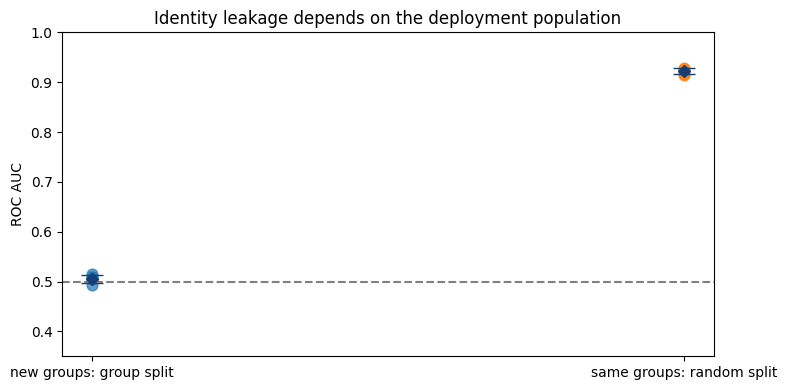

In [3]:
"""Quantify the deployment question that random versus grouped CV actually answers."""
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def run():
    rows = []
    for seed in (11, 22, 33, 44, 55):
        df = grouped(seed)
        x, y = df.drop(columns="target"), df.target
        random_train, random_test = train_test_split(np.arange(len(df)), test_size=.25, stratify=y, random_state=seed)
        group_train, group_test = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=seed).split(x, y, df.group_id))
        for protocol, tr, te in (("same groups: random split", random_train, random_test), ("new groups: group split", group_train, group_test)):
            preprocess = ColumnTransformer([("group", OneHotEncoder(handle_unknown="ignore"), ["group_id"]), ("numeric", StandardScaler(), ["sensor_noise"])])
            model = make_pipeline(preprocess, LogisticRegression(max_iter=1000))
            model.fit(x.iloc[tr], y.iloc[tr])
            overlap = len(set(df.group_id.iloc[tr]) & set(df.group_id.iloc[te]))
            if protocol.startswith("new"):
                assert overlap == 0
            rows.append({"seed": seed, "protocol": protocol, "auc": roc_auc_score(y.iloc[te], model.predict_proba(x.iloc[te])[:, 1]), "overlapping_groups": overlap})
    result = pd.DataFrame(rows)
    print(result.to_string(index=False))
    print(result.groupby("protocol").auc.agg(["mean", "std"]))
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (protocol, frame) in enumerate(result.groupby("protocol")):
        ax.scatter(np.full(len(frame), i), frame.auc, s=60, alpha=.7)
        ax.errorbar(i, frame.auc.mean(), yerr=frame.auc.std(), color="#153e75", fmt="D", capsize=8)
    ax.set_xticks([0, 1], sorted(result.protocol.unique()))
    ax.set(ylim=(.35, 1), ylabel="ROC AUC", title="Identity leakage depends on the deployment population")
    ax.axhline(.5, ls="--", color="gray")
    fig.tight_layout()
    out = Path("outputs"); out.mkdir(exist_ok=True)
    result.to_csv(out / "group-validation.csv", index=False)
    fig.savefig(out / "group-validation.png", dpi=160)
    plt.show()
    return result


results = run()

## Interpretation and limitations

Across five seeds, the random split scores about 0.922 AUC and the new-group split about 0.506. This demonstrates a mismatch of evaluation populations, not a universal argument against random splitting. A group-ID shortcut is valid if deployment truly reuses those identities and the relationship remains stable.

**Reference:** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html

Reproduce first, then adapt the protocol to the population and metric of your own task.